# MovieLens Analysis with PySpark

This notebook analyzes the MovieLens dataset using PySpark.

The main goals are:
- identify the most active users
- find the highest-rated movies
- define and detect popular movies
- determine the most popular genre for each day of the week
- answer one additional analytical question using extra Spark functionality

The notebook uses joins, aggregations, date/time functions, string functions, window functions, and visualizations.

# Spark setup

In [13]:
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
!wget -q https://downloads.apache.org/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz
!tar xf spark-3.5.1-bin-hadoop3.tgz
!pip install -q findspark

tar: spark-3.5.1-bin-hadoop3.tgz: Cannot open: No such file or directory
tar: Error is not recoverable: exiting now


In [14]:
import os

for var in ["SPARK_HOME", "PYSPARK_PYTHON", "PYSPARK_DRIVER_PYTHON"]:
    if var in os.environ:
        del os.environ[var]

print("Old Spark env vars removed")

Old Spark env vars removed


In [15]:
!apt-get install -qq openjdk-17-jdk-headless
!pip install -q pyspark

In [16]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

print(os.environ["JAVA_HOME"])

/usr/lib/jvm/java-17-openjdk-amd64


# Imports

In [56]:
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.sql.functions import *
from pyspark.sql.window import Window
import matplotlib.pyplot as plt

In [18]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("HW2_Spark") \
    .master("local[*]") \
    .getOrCreate()

print("Spark version:", spark.version)

Spark version: 4.0.2


In [19]:
spark

#Load data

## Schemas

In [20]:
movies_schema = StructType([
    StructField("movieId", IntegerType(), True),
    StructField("title", StringType(), True),
    StructField("genres", StringType(), True)
])

In [34]:
ratings_schema = StructType([
    StructField("userId", IntegerType(), True),
    StructField("movieId", IntegerType(), True),
    StructField("rating", FloatType(), True),
    StructField("timestamp", TimestampType(), True)
])

Instead of using inferSchema, the schemas were defined manually.  
This approach gives better control over data types, improves reproducibility, and avoids incorrect automatic type inference.


## Read data

In [39]:
movies = spark.read.csv(
    "/content/movie.csv",
    header=True,
    schema=movies_schema
)

In [40]:
ratings = spark.read.csv(
    "/content/rating.csv",
    header=True,
    schema=ratings_schema
)

In [41]:
movies.printSchema()
ratings.printSchema()

root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)

root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: float (nullable = true)
 |-- timestamp: timestamp (nullable = true)



In [42]:
movies.show(5, truncate=False)
ratings.show(5, truncate=False)

+-------+----------------------------------+-------------------------------------------+
|movieId|title                             |genres                                     |
+-------+----------------------------------+-------------------------------------------+
|1      |Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fantasy|
|2      |Jumanji (1995)                    |Adventure|Children|Fantasy                 |
|3      |Grumpier Old Men (1995)           |Comedy|Romance                             |
|4      |Waiting to Exhale (1995)          |Comedy|Drama|Romance                       |
|5      |Father of the Bride Part II (1995)|Comedy                                     |
+-------+----------------------------------+-------------------------------------------+
only showing top 5 rows
+------+-------+------+-------------------+
|userId|movieId|rating|timestamp          |
+------+-------+------+-------------------+
|1     |2      |3.5   |2005-04-02 23:53:47|

#Data Preparation and Feature Engineering

At this stage, the goal is to prepare the datasets for further analysis.

Although the data has already been loaded successfully, additional preprocessing is required before answering the analytical questions. In particular, the ratings dataset contains a timestamp column that can be used for time-based analysis. To make this information more useful, new date-related features will be created, such as the calendar date, the numeric day of the week, and the day name.

After that, the ratings dataset will be joined with the movies dataset. This step is necessary because the ratings file contains user evaluations, while the movies file contains movie titles and genres. By combining these two datasets, we will create one main DataFrame that includes both rating information and movie metadata, which will be used throughout the rest of the analysis.

## Date-related columns

In [46]:
ratings_prepared = ratings.withColumn(
    "rating_date", to_date(col("timestamp"))
).withColumn(
    "day_of_week_num", dayofweek(col("timestamp"))
).withColumn(
    "day_of_week", date_format(col("timestamp"), "EEEE")
)

## Join

In [48]:
movie_ratings = ratings_prepared.join(movies, on="movieId", how="inner")

In [49]:
movie_ratings.show(5, truncate=False)

+-------+------+------+-------------------+-----------+---------------+-----------+---------------------------------------------------------------+--------------------------------------+
|movieId|userId|rating|timestamp          |rating_date|day_of_week_num|day_of_week|title                                                          |genres                                |
+-------+------+------+-------------------+-----------+---------------+-----------+---------------------------------------------------------------+--------------------------------------+
|2      |1     |3.5   |2005-04-02 23:53:47|2005-04-02 |7              |Saturday   |Jumanji (1995)                                                 |Adventure|Children|Fantasy            |
|29     |1     |3.5   |2005-04-02 23:31:16|2005-04-02 |7              |Saturday   |City of Lost Children, The (Cité des enfants perdus, La) (1995)|Adventure|Drama|Fantasy|Mystery|Sci-Fi|
|32     |1     |3.5   |2005-04-02 23:33:39|2005-04-02 |7         

# Questions

## Question 1. Top 5 Most Active Users

In this task, user activity is measured by the number of ratings each user has submitted.

Identifying the most active users helps to understand participation patterns in the dataset and highlights users who contribute the most to the recommendation system. These users may have a significant influence on overall rating distributions.

In [52]:
top_active_users = ratings.groupBy("userId") \
    .agg(count("*").alias("num_ratings")) \
    .orderBy(desc("num_ratings")) \
    .limit(5)

In [54]:
top_active_users_pd = top_active_users.toPandas()

For visualization, the result is converted to a Pandas DataFrame.

PySpark does not support direct plotting, so Pandas is used together with Matplotlib. Since only a small subset of the data is involved, this conversion is efficient and does not affect performance.

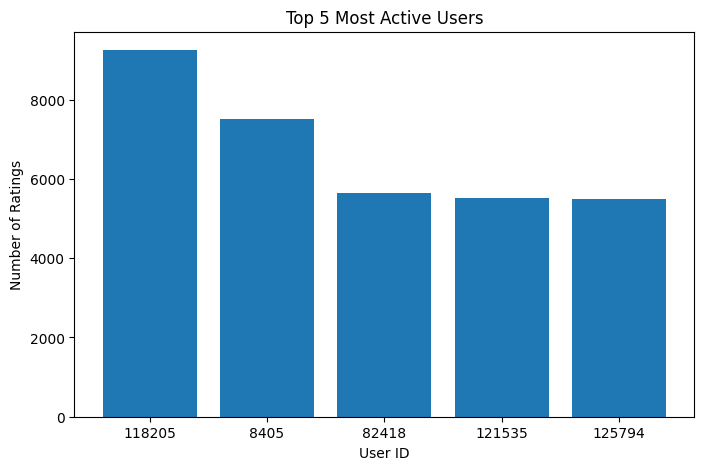

In [55]:
plt.figure(figsize=(8,5))
plt.bar(top_active_users_pd["userId"].astype(str), top_active_users_pd["num_ratings"])

plt.title("Top 5 Most Active Users")
plt.xlabel("User ID")
plt.ylabel("Number of Ratings")

plt.show()

The results indicate that user activity is unevenly distributed.

A small number of users contribute a large portion of the ratings, with the top user significantly outperforming the others. This suggests that the dataset is driven by highly active individuals, which may influence overall rating patterns.

## Question 2. Top 5 Highest-Rated Movies

In this task, we aim to identify the movies with the highest average ratings.

However, using average ratings alone can be misleading, as movies with very few ratings may appear at the top. To ensure more reliable results, only movies with a minimum number of ratings are considered.

In this analysis, a threshold of at least 50 ratings is applied to filter out less representative cases.

In [57]:
movie_avg_ratings = movie_ratings.groupBy("movieId", "title") \
    .agg(
        avg("rating").alias("avg_rating"),
        count("rating").alias("num_ratings")
    )

In [58]:
top_rated_movies = movie_avg_ratings \
    .filter(col("num_ratings") >= 50) \
    .orderBy(desc("avg_rating"), desc("num_ratings")) \
    .limit(5)

In [60]:
top_rated_movies_pd = top_rated_movies.toPandas()

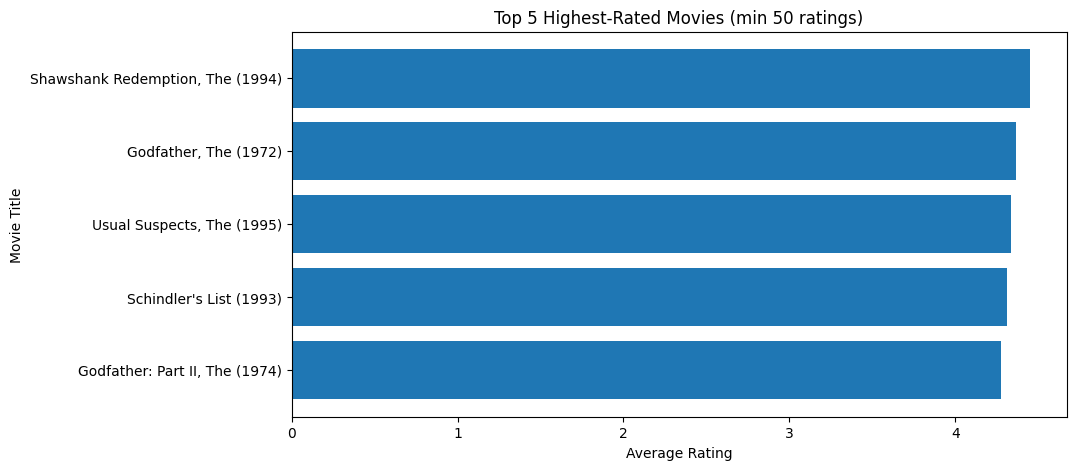

In [63]:
plt.figure(figsize=(10,5))

plt.barh(top_rated_movies_pd["title"], top_rated_movies_pd["avg_rating"])

plt.title("Top 5 Highest-Rated Movies (min 50 ratings)")
plt.xlabel("Average Rating")
plt.ylabel("Movie Title")

plt.gca().invert_yaxis()

plt.show()

The visualization presents the top 5 highest-rated movies after applying a minimum rating threshold.

All selected movies have very high average ratings, indicating strong audience approval. The differences between their ratings are relatively small, which suggests that these top movies are similarly well-received by viewers.

By filtering out movies with fewer than 50 ratings, the results become more reliable and less affected by extreme values from small samples. This ensures that the identified movies reflect consistent user satisfaction rather than isolated opinions.

Overall, the results highlight a group of movies that combine both high quality (as perceived by users) and sufficient engagement.

## Question 3. Popular Movies

In this task, we define what a “popular” movie is.

Popularity is not necessarily the same as quality. While highly rated movies reflect user satisfaction, popular movies reflect audience engagement and attention.

In this analysis, a movie is considered popular if it has received at least 1000 ratings. This threshold ensures that only widely viewed and frequently rated movies are included.

This definition focuses on the level of user interaction rather than rating scores.

In [64]:
popular_movies = movie_ratings.groupBy("movieId", "title") \
    .agg(
        count("rating").alias("num_ratings"),
        avg("rating").alias("avg_rating")
    )

In [65]:
popular_movies_filtered = popular_movies \
    .filter(col("num_ratings") >= 1000) \
    .orderBy(desc("num_ratings"))

In [67]:
popular_movies_pd = popular_movies_filtered.limit(20).toPandas()

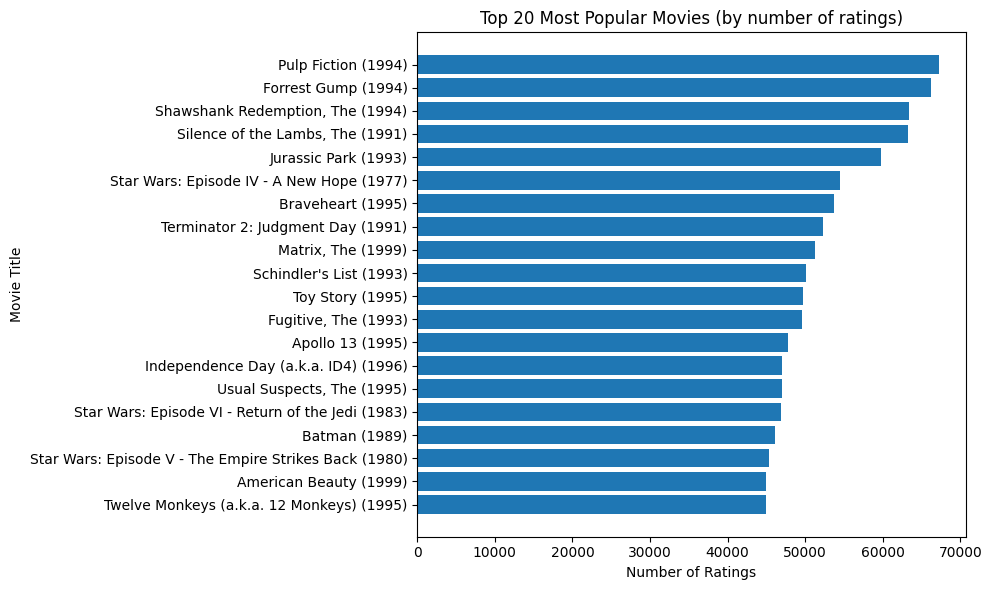

In [68]:
plt.figure(figsize=(10,6))

plt.barh(popular_movies_pd["title"], popular_movies_pd["num_ratings"])

plt.title("Top 20 Most Popular Movies (by number of ratings)")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie Title")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The visualization highlights the most popular movies based on the total number of ratings.

The results show that a group of well-known and widely recognized films, such as *Pulp Fiction*, *Forrest Gump*, and *The Shawshank Redemption*, have received the highest number of ratings. This indicates that these movies have reached a broad audience and maintained long-term popularity.

Unlike the previous analysis focused on average ratings, this chart emphasizes audience engagement. Many of the movies listed here are not only critically acclaimed but also widely viewed, suggesting that popularity is often associated with cultural impact and mainstream appeal.

Additionally, the distribution appears relatively gradual, with no extreme outlier dominating the chart. This suggests that popularity is shared among several major films rather than concentrated in a single title.

## Question 4. Most Popular Genre by Day of the Week

In this task, the goal is to identify the most popular movie genre for each day of the week.

Since movies can belong to multiple genres, the `genres` column must first be split into individual values. Each genre is then analyzed separately by counting how many ratings it receives on each day.

Finally, a window function is used to determine the most popular genre (i.e., the one with the highest number of ratings) for each day of the week.

In [69]:
genres_exploded = movie_ratings.withColumn(
    "genre_array", split(col("genres"), "\\|")
).withColumn(
    "genre", explode(col("genre_array"))
)

In [70]:
genres_exploded.select("title", "genres", "genre", "day_of_week").show(5, truncate=False)

+---------------------------------------------------------------+--------------------------------------+---------+-----------+
|title                                                          |genres                                |genre    |day_of_week|
+---------------------------------------------------------------+--------------------------------------+---------+-----------+
|Jumanji (1995)                                                 |Adventure|Children|Fantasy            |Adventure|Saturday   |
|Jumanji (1995)                                                 |Adventure|Children|Fantasy            |Children |Saturday   |
|Jumanji (1995)                                                 |Adventure|Children|Fantasy            |Fantasy  |Saturday   |
|City of Lost Children, The (Cité des enfants perdus, La) (1995)|Adventure|Drama|Fantasy|Mystery|Sci-Fi|Adventure|Saturday   |
|City of Lost Children, The (Cité des enfants perdus, La) (1995)|Adventure|Drama|Fantasy|Mystery|Sci-Fi|Drama  

In [71]:
genre_day_counts = genres_exploded.groupBy(
    "day_of_week_num", "day_of_week", "genre"
).agg(
    count("*").alias("rating_count")
)

In [72]:
window_spec = Window.partitionBy("day_of_week_num").orderBy(desc("rating_count"))

In [73]:
most_popular_genre = genre_day_counts.withColumn(
    "rank", row_number().over(window_spec)
).filter(
    col("rank") == 1
).orderBy("day_of_week_num")

In [74]:
most_popular_genre.show(truncate=False)

+---------------+-----------+-----+------------+----+
|day_of_week_num|day_of_week|genre|rating_count|rank|
+---------------+-----------+-----+------------+----+
|1              |Sunday     |Drama|1302020     |1   |
|2              |Monday     |Drama|1381410     |1   |
|3              |Tuesday    |Drama|1347704     |1   |
|4              |Wednesday  |Drama|1252007     |1   |
|5              |Thursday   |Drama|1191297     |1   |
|6              |Friday     |Drama|1204803     |1   |
|7              |Saturday   |Drama|1178612     |1   |
+---------------+-----------+-----+------------+----+



In [75]:
genre_day_pd = most_popular_genre.toPandas()

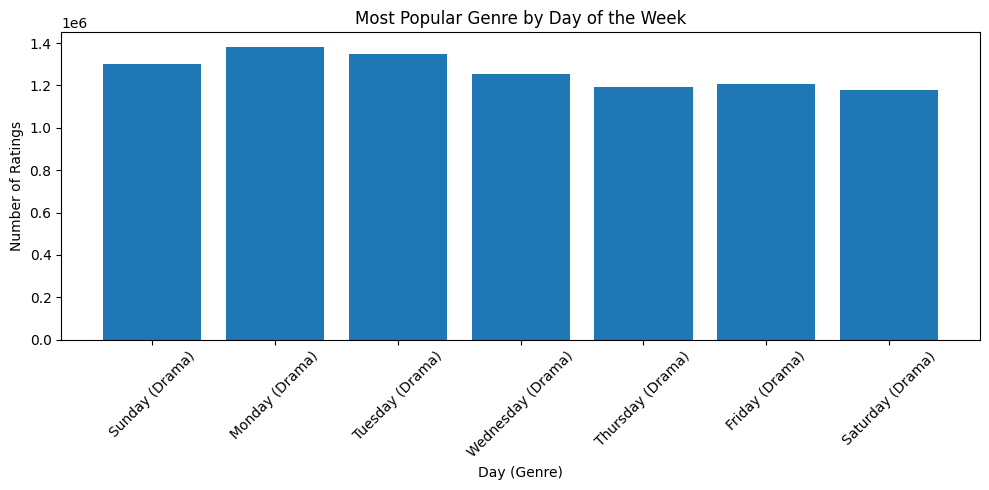

In [77]:
genre_day_pd["label"] = genre_day_pd["day_of_week"] + " (" + genre_day_pd["genre"] + ")"

plt.figure(figsize=(10,5))

plt.bar(genre_day_pd["label"], genre_day_pd["rating_count"])

plt.title("Most Popular Genre by Day of the Week")
plt.xlabel("Day (Genre)")
plt.ylabel("Number of Ratings")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

To identify the most popular genre for each day of the week, the following steps were performed:

1. The `genres` column was split into multiple values using the `split()` function, since each movie may belong to several genres.
2. The resulting array was expanded using `explode()`, creating a separate row for each genre.
3. The data was grouped by `day_of_week` and `genre`, and the number of ratings was counted for each combination.
4. A window function (`row_number()`) was applied to rank genres within each day based on the number of ratings.
5. Finally, the top-ranked genre (i.e., the most popular one) was selected for each day of the week.


The results show that certain genres consistently dominate user engagement across different days, indicating stable viewing preferences over time.

## Question 5. User Rating Consistency Analysis

In this task, we analyze how consistent users are in their rating behavior.

Different users may have different rating habits: some tend to give consistently high or low ratings, while others vary their scores significantly. To capture this behavior, we calculate the standard deviation of ratings for each user.

A low standard deviation indicates consistent rating behavior, while a high value suggests that the user evaluates movies more variably.

This analysis helps to better understand user behavior patterns and can be useful for improving recommendation systems.

In [78]:
user_consistency = ratings.groupBy("userId") \
    .agg(
        count("rating").alias("num_ratings"),
        stddev("rating").alias("rating_stddev")
    )

In [79]:
user_consistency_filtered = user_consistency \
    .filter(col("num_ratings") >= 50)

**Inconsistent users**

In [80]:
most_inconsistent_users = user_consistency_filtered \
    .orderBy(desc("rating_stddev")) \
    .limit(10)

most_inconsistent_users.show()

+------+-----------+------------------+
|userId|num_ratings|     rating_stddev|
+------+-----------+------------------+
| 30874|         58|2.2558655145200315|
|105792|        120|2.2544074479065377|
| 67439|         66|2.2433533008944515|
| 58576|         58| 2.125522603970116|
| 33634|        233| 2.108367667720219|
|117120|         63|2.0818504707323435|
|   741|       2212| 2.040571665022279|
|  3649|        125| 2.016040514185841|
|  5895|        108|2.0120354381474925|
| 41852|         61|1.9989068050563406|
+------+-----------+------------------+



**Consistent users**

In [81]:
most_consistent_users = user_consistency_filtered \
    .orderBy("rating_stddev") \
    .limit(10)

most_consistent_users.show()

+------+-----------+-------------+
|userId|num_ratings|rating_stddev|
+------+-----------+-------------+
| 65309|         50|          0.0|
| 73479|        147|          0.0|
|125802|         53|          0.0|
|119100|         57|          0.0|
| 72369|         51|          0.0|
| 96845|         50|          0.0|
| 18646|        203|          0.0|
| 93230|         52|          0.0|
| 42101|        100|          0.0|
|119345|         97|          0.0|
+------+-----------+-------------+



In [83]:
user_consistency_pd = user_consistency_filtered.toPandas()

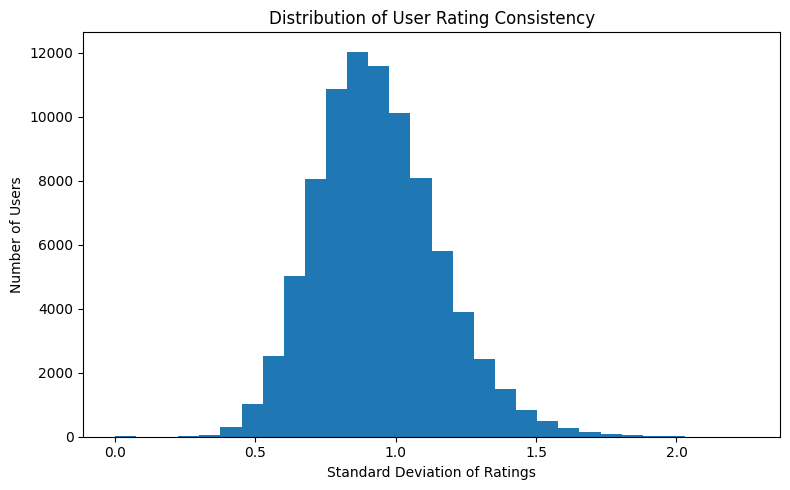

In [84]:
plt.figure(figsize=(8,5))

plt.hist(user_consistency_pd["rating_stddev"], bins=30)

plt.title("Distribution of User Rating Consistency")
plt.xlabel("Standard Deviation of Ratings")
plt.ylabel("Number of Users")

plt.tight_layout()
plt.show()

To analyze user rating behavior, we measured how consistent users are in their evaluations.

1. The ratings dataset was grouped by `userId`.
2. For each user, two metrics were calculated:
   - The total number of ratings (`num_ratings`)
   - The standard deviation of ratings (`rating_stddev`)
3. Users with a low number of ratings were filtered out to ensure reliable results.
4. The distribution of rating standard deviation was visualized using a histogram.

The standard deviation is used as a measure of consistency: lower values indicate more consistent ratings, while higher values indicate more variability in user behavior.

The distribution shows that most users have moderate variability in their ratings, while only a small number of users exhibit very high or very low consistency.

This suggests that user behavior is generally balanced, with most users neither being extremely strict nor overly generous in their evaluations.

# Conclusion

In this analysis, the MovieLens dataset was explored using Apache Spark to uncover patterns in user behavior and movie characteristics.

The results showed that user activity is highly uneven, with a small number of users contributing a large portion of the ratings. Additionally, while some movies achieve high average ratings, popularity is better reflected by the number of ratings, highlighting the difference between quality and engagement.

The genre analysis revealed that user preferences remain relatively stable throughout the week, with certain genres consistently dominating across different days. This suggests predictable viewing patterns and strong genre preferences.

Finally, the user consistency analysis demonstrated that most users exhibit moderate variability in their ratings, while only a small group shows extreme behavior. This highlights the diversity in user evaluation styles and emphasizes the importance of personalization in recommendation systems.

Overall, the combination of aggregation, joins, window functions, and statistical analysis provided a comprehensive understanding of the dataset and demonstrated the effectiveness of Spark for large-scale data analysis.